In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch
import torch.nn as nn
from torch.nn.modules.conv import Conv2d
from torchvision import transforms

/Users/ishaan/miniconda3/envs/VisualSearch/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/ishaan/miniconda3/envs/VisualSearch/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <CFED5F8E-EC3F-36FD-AAA3-2C6C7F8D3DD9> /Users/ishaan/miniconda3/envs/VisualSearch/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <8E6D6BF5-9658-33B9-9D3C-DF587B2F99E7> /Users/ishaan/miniconda3/envs/VisualSearch/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
class IVSN(nn.Module):
  def __init__(self, model):
      super(IVSN, self).__init__()
      self.features = nn.Sequential(*list(model.children())[0][:30])
      for param in self.features.parameters():
        param.requires_grad_ = False

  def forward(self, x):
      x = self.features(x)
      return x

ConvSize, NumTemplates, Mylayer = 1, 512, 31
TotalTrials, targetsize, stimulisize = 240, (640, 480), (1280, 1024)
MMconv = Conv2d(NumTemplates, 1, kernel_size = (ConvSize, ConvSize), stride = (1, 1), padding = (1, 1))
# 512 input channels, 1 output channel, 1x1 kernel, stride 1, padding 1

In [5]:
from torchvision.models import VGG16_Weights

model_vgg = torch.hub.load('pytorch/vision:v0.10.0', 'vgg16', weights=VGG16_Weights.DEFAULT)
model_ivsn = IVSN(model_vgg)

Using cache found in /Users/ishaan/.cache/torch/hub/pytorch_vision_v0.10.0


In [6]:
import importlib
from naturalSceneDataset import NaturalSceneDataset

input_images = NaturalSceneDataset('data/naturaldesign/gt', 'data/naturaldesign/stimuli', 'data/naturaldesign/target', normalize_means=[0.485, 0.456, 0.406], normalize_stds=[0.229, 0.224, 0.225])

Original img shape: (3, 1024, 1280)
Original img dtype: float32
Processed img shape: (1024, 1280)
Processed img dtype: uint8
Edge density: 0.2664794921875
searching at (74, 982)
searching at (431, 982)
searching at (330, 982)
searching at (0, 881)
False
[4]


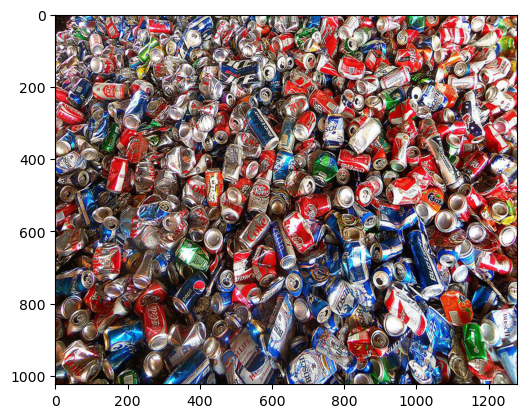

In [24]:
import torch
from tqdm import trange
from utils import naturalSearchProcesswithPath, naturalSearchProcesswithPathFixedN, naturalSearchProcesswithPathNaiveGaussian, compute_edge_density
from utils import naturalSearchProcesswithPathNaiveEvidenceAccumulation
import matplotlib.pyplot as plt
import numpy as np

num_pics = len(input_images) #240 images
IVSN_attention_map, scanpath = {}, {}
IVSN_res = list()

with torch.no_grad():
    for id in range(1):
        stimuli_img, target_img, bbox = input_images[id]
        #Need 3 channels:
        if stimuli_img.shape[0] == 1:
            stimuli_img = torch.cat((stimuli_img, stimuli_img, stimuli_img), 0)
        if target_img.shape[0] == 1:
            target_img = torch.cat((target_img, target_img, target_img), 0)

        edge_density = compute_edge_density(stimuli_img)
        
        
        stimuli_batch = stimuli_img.unsqueeze(0)
        target_batch = target_img.unsqueeze(0) 
        
        # Get the output from the model after going through all 30 layers
        stimuli_output = model_ivsn(stimuli_batch)
        target_output = model_ivsn(target_batch)
        
        # Update MMconv weights with target output
        MMconv.weight = torch.nn.Parameter(target_output)
        
        # Get the attention map by applying MMconv to stimuli_output
        attention_IVSN = MMconv(stimuli_output) 
        attention_IVSN = attention_IVSN.squeeze(0)
                
        # Normalize the attention map
        mask_IVSN = transforms.Resize((stimuli_img.shape[1], stimuli_img.shape[2]))(attention_IVSN)
        mask_IVSN = mask_IVSN.squeeze(0)
        mask_IVSN = torch.divide(mask_IVSN, mask_IVSN.max())
                        
        IVSN_attention_map[id] = mask_IVSN.clone().detach() #create deepcopy
        
        IVSN_num, path, result = naturalSearchProcesswithPathNaiveEvidenceAccumulation(mask_IVSN, bbox, np.exp(edge_density))
        scanpath[id] = path
        IVSN_res.append(IVSN_num)
        print(result)

print(IVSN_res)

plt.imshow(stimuli_img.permute(1, 2, 0))

In [ ]:
#Might need to split up the image into a bunch of images and concatenate -- later